# Chapter 5: Linear Models and Regularization

## 1. Ringkasan Bab
Regresi linear merupakan teknik dasar pemodelan prediktif untuk memetakan hubungan fungsional antara variabel fitur independen dengan variabel target kontinu. Bab ini membahas pendekatan regresi dari Ordinary Least Squares (OLS) dasar hingga teknik regularisasi dan ekspansi non-linier:
- **Ordinary Least Squares (OLS)**: Penaksiran parameter menggunakan minimalisasi jumlah kuadrat sisa (*sum of squared residuals*).
- **Masalah Multikolinearitas & Overfitting**: Dampak buruk korelasi antar-fitur terhadap inflasi bobot koefisien dan instabilitas model.
- **Regularisasi Ridge (L2)**: Penambahan penalti kuadrat magnitudo koefisien untuk penyusutan (*shrinkage*) bobot tanpa mengeliminasi fitur.
- **Regularisasi Lasso (L1)**: Penambahan penalti nilai absolut koefisien yang mendorong kelangkaan (*sparsity*) dan seleksi fitur otomatis.
- **ElasticNet**: Kombinasi seimbang antara penalti L1 dan L2 melalui parameter rasio pencampuran (*l1_ratio*).
- **Pemodelan Non-Linier**: Ekspansi fitur berderajat tinggi menggunakan `PolynomialFeatures` serta pendekatan regresi kontinu menggunakan `SplineTransformer`.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings

# Pengaturan random state dan penekanan pesan peringatan
np.random.seed(2024)
warnings.filterwarnings('ignore')

print("Pustaka dan modul Chapter 5 berhasil dimuat.")

Pustaka dan modul Chapter 5 berhasil dimuat.


## 2. Ordinary Least Squares (OLS) dan Tantangan Multikolinearitas

### 2.1 Formulasi Matematis Regresi Linear
Model regresi linear mengasumsikan hubungan linier antara input $\mathbf{x} = (x_1, \dots, x_p)$ dan target $y$:
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p + \epsilon = \mathbf{x}^T \boldsymbol{\beta} + \epsilon$$

Parameter $\boldsymbol{\beta}$ diestimasi dengan meminimalkan fungsi kerugian sisa kuadrat:
$$\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2$$
Solusi bentuk tertutupnya (*closed-form solution*):
$$\hat{\boldsymbol{\beta}} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

### 2.2 Bahaya Multikolinearitas
Ketika sejumlah fitur memiliki korelasi tinggi, matriks $\mathbf{X}^T \mathbf{X}$ mendekati singular (nilai eigen mendekati nol). Akibatnya, estimasi koefisien menjadi sangat tidak stabil: perubahan kecil pada data latih dapat mengubah tanda atau melipatgandakan nilai bobot secara ekstrem.

In [4]:
# Pembuatan Dataset Sintetis Regresi dengan Multikolinearitas Tinggi
X, y = make_regression(
    n_samples=1000, n_features=100, n_informative=10, noise=20, random_state=123
)

# Menyuntikkan multikolinearitas (fitur 50-99 berkorelasi kuat dengan fitur 0-49)
for i in range(50, 100):
    X[:, i] = X[:, i-50] + np.random.normal(0, 0.1, size=1000)

feature_names = [f'feature_{i}' for i in range(100)]
X_plot = X[:, 0].reshape(-1, 1)

# Menskalakan target dan menambahkan komponen non-linier
y = y * 1000
y = y + np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel() / 10)

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Bentuk data: {X.shape[0]} sampel, {X.shape[1]} fitur")
print(f"Fitur informatif : 10 dari 100")
print(f"Fitur berkorelasi: 50 fitur (fitur 50-99)")
print(f"Standar deviasi target: {y.std():.2f}")

Bentuk data: 1000 sampel, 100 fitur
Fitur informatif : 10 dari 100
Fitur berkorelasi: 50 fitur (fitur 50-99)
Standar deviasi target: 223820.65


In [5]:
# Membagi Data dan Melatih Linear Regression (OLS)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)
l2_norm_linear = np.sqrt(np.sum(linear_model.coef_**2))

print("=== Performa Linear Regression (OLS) ===")
print(f"Mean Squared Error (MSE): {mse_linear:.2f}")
print(f"R-squared (R2)          : {r2_linear:.4f}")
print(f"Norm L2 Koefisien       : {l2_norm_linear:.2f}")
print(f"Rentang Nilai Koefisien : [{linear_model.coef_.min():.2f}, {linear_model.coef_.max():.2f}]")

=== Performa Linear Regression (OLS) ===
Mean Squared Error (MSE): 43406762489.12
R-squared (R2)          : 0.1279
Norm L2 Koefisien       : 700689.23
Rentang Nilai Koefisien : [-163082.12, 147618.87]


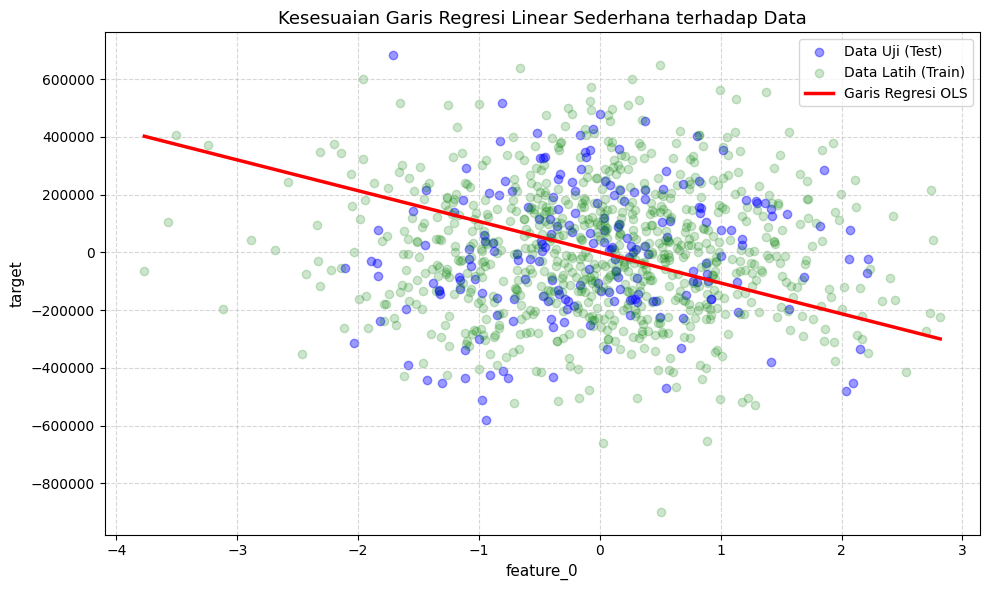

In [6]:
# Visualisasi Proyeksi Garis Regresi OLS (Menggunakan feature_0)
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.4, label='Data Uji (Test)')
plt.scatter(X_train[:, 0], y_train, color='green', alpha=0.2, label='Data Latih (Train)')

X_line = np.linspace(df['feature_0'].min(), df['feature_0'].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()

y_line = linear_model.predict(pd.DataFrame(X_line_full, columns=feature_names))

plt.plot(X_line, y_line, color='red', linewidth=2.5, label='Garis Regresi OLS')
plt.xlabel('feature_0', fontsize=11)
plt.ylabel('target', fontsize=11)
plt.title('Kesesuaian Garis Regresi Linear Sederhana terhadap Data', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Regularisasi Ridge (L2) dan Lasso (L1)

Teknik regularisasi menambahkan suku penalti ke dalam fungsi tujuan optimasi untuk membatasi magnitudo bobot koefisien:

1. **Ridge Regression (L2)**:
   $$\mathcal{L}_{\text{Ridge}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} \beta_j^2$$
   - Menyusutkan koefisien mendekati nol secara proporsional.
   - Efektif meredam variansi akibat multikolinearitas namun tetap mempertahankan seluruh variabel di dalam model.

2. **Lasso Regression (L1)**:
   $$\mathcal{L}_{\text{Lasso}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} |\beta_j|$$
   - Penalti L1 memiliki geometri bersudut lancip pada kontur pembatas, memungkinkan sejumlah koefisien ditekan tepat ke angka nol.
   - Bertindak secara simultan sebagai mekanisme seleksi fitur otomatis (*sparse model*).

In [7]:
# Melatih Model Ridge dan Lasso Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)
lasso_model.fit(X_train, y_train)

# Prediksi Data Uji
y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)

# Komparasi Metrik Evaluasi
metrics = {
    'Model': ['Ridge Regression', 'Lasso Regression', 'Linear Regression (OLS)'],
    'Mean Squared Error': [
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mse_linear
    ],
    'R-squared': [
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso),
        r2_linear
    ],
    'Norm L2 Koefisien': [
        np.sqrt(np.sum(ridge_model.coef_**2)),
        np.sqrt(np.sum(lasso_model.coef_**2)),
        l2_norm_linear
    ],
    'Jumlah Fitur Non-Nol': [
        np.sum(ridge_model.coef_ != 0),
        np.sum(lasso_model.coef_ != 0),
        np.sum(linear_model.coef_ != 0)
    ]
}

metrics_df = pd.DataFrame(metrics).sort_values('Mean Squared Error', ascending=True)
display(metrics_df.style.format({
    'Mean Squared Error': '{:.2f}',
    'R-squared': '{:.4f}',
    'Norm L2 Koefisien': '{:.2f}'
}))

,Model,Mean Squared Error,R-squared,Norm L2 Koefisien,Jumlah Fitur Non-Nol
0,Ridge Regression,42930147665.94,0.1375,538616.60,100
1,Lasso Regression,43352039348.94,0.1290,680349.47,99
2,Linear Regression (OLS),43406762489.12,0.1279,700689.23,100


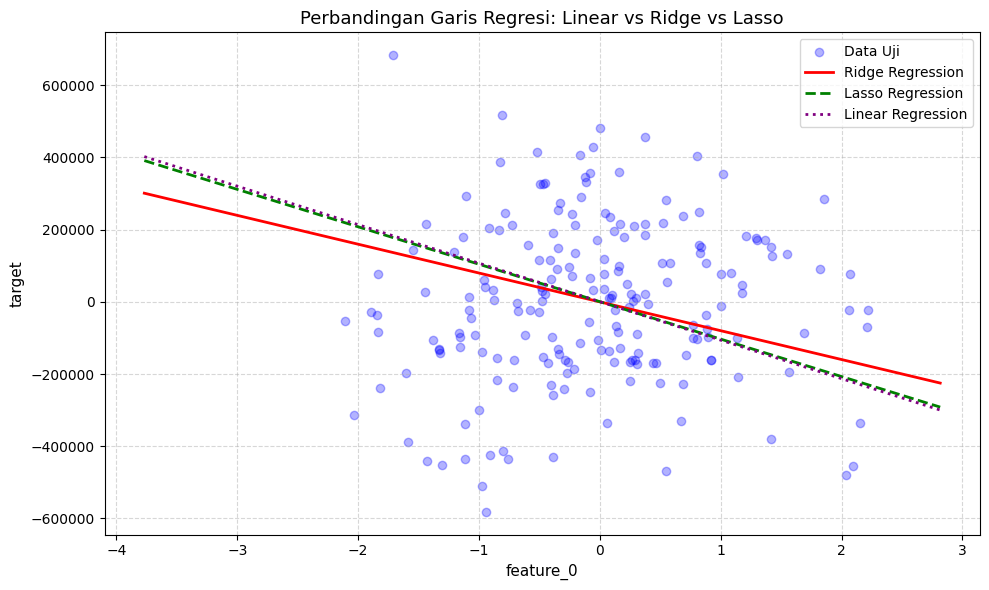

In [8]:
# Komparasi Visual Garis Prediksi: OLS vs Ridge vs Lasso
plt.figure(figsize=(10, 6))
plt.scatter(X_test[:, 0], y_test, color='blue', alpha=0.3, label='Data Uji')

y_line_ridge = ridge_model.predict(pd.DataFrame(X_line_full, columns=feature_names))
y_line_lasso = lasso_model.predict(pd.DataFrame(X_line_full, columns=feature_names))

plt.plot(X_line, y_line_ridge, color='red', linewidth=2, label='Ridge Regression')
plt.plot(X_line, y_line_lasso, color='green', linestyle='--', linewidth=2, label='Lasso Regression')
plt.plot(X_line, y_line, color='purple', linestyle=':', linewidth=2, label='Linear Regression')

plt.xlabel('feature_0', fontsize=11)
plt.ylabel('target', fontsize=11)
plt.title('Perbandingan Garis Regresi: Linear vs Ridge vs Lasso', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Regularisasi ElasticNet dan Analisis Lintasan Koefisien

ElasticNet menggabungkan penalti L1 dan L2 ke dalam satu fungsi kerugian:
$$\mathcal{L}_{\text{ElasticNet}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \left( \rho \sum_{j=1}^{p} \vert{}\beta_j\vert{} + \frac{1 - \rho}{2} \sum_{j=1}^{p} \beta_j^2 \right)$$

Parameter kendali:
- $\alpha$: Mengontrol kekuatan penalti regularisasi secara keseluruhan.
- $\rho$ (`l1_ratio`): Mengatur rasio percampuran antara penalti Lasso ($\rho = 1$) dan Ridge ($\rho = 0$).

ElasticNet ideal digunakan ketika fitur-fitur berkorelasi satu sama lain dalam kelompok (mengatasi kelemahan Lasso yang cenderung memilih satu fitur acak dari kelompok fitur yang saling berkorelasi).

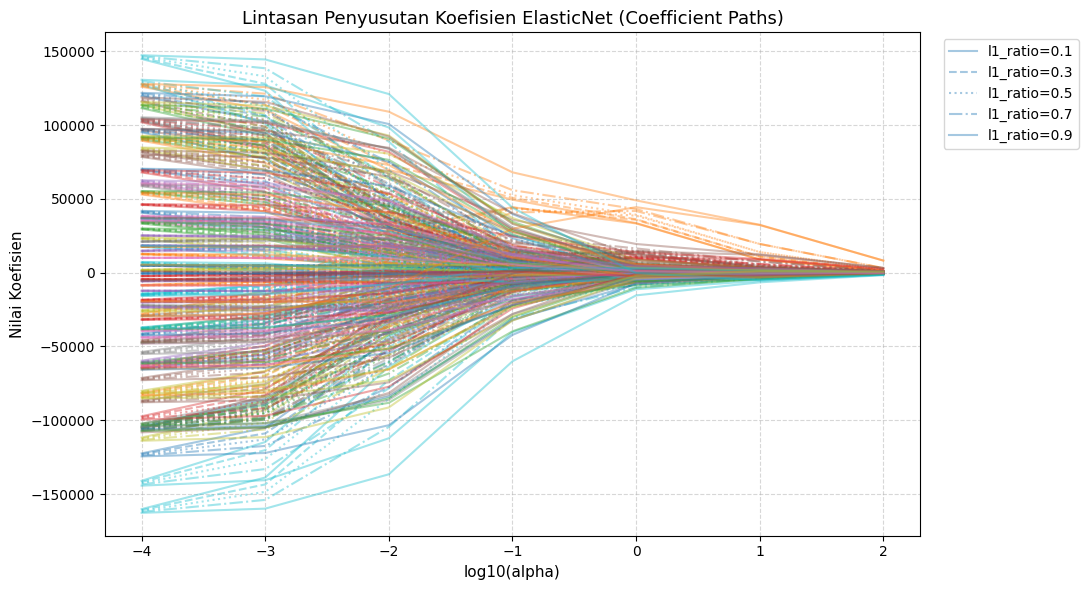

,Model,Mean Squared Error,R-squared,Norm L2 Koefisien,Jumlah Fitur Non-Nol
3,ElasticNet Regression,42634873340.85,0.1434,66677.26,100
0,Ridge Regression,42930147665.94,0.1375,538616.60,100
1,Lasso Regression,43352039348.94,0.1290,680349.47,99
2,Linear Regression (OLS),43406762489.12,0.1279,700689.23,100


In [9]:
# Evaluasi Lintasan Koefisien ElasticNet (Coefficient Paths)
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

plt.figure(figsize=(11, 6))

for l1_ratio in l1_ratios:
    coefs = []
    for a in alphas:
        el_mod = ElasticNet(
            alpha=a, l1_ratio=l1_ratio, random_state=123, max_iter=10000, tol=1e-4
        )
        el_mod.fit(X_train, y_train)
        coefs.append(el_mod.coef_)

    coefs_arr = np.array(coefs)
    for f_idx in range(X_train.shape[1]):
        plt.plot(
            np.log10(alphas),
            coefs_arr[:, f_idx],
            label=f'l1_ratio={l1_ratio}' if f_idx == 0 else "",
            alpha=0.4,
            linestyle=['solid', 'dashed', 'dotted', 'dashdot', '-'][l1_ratios.index(l1_ratio)]
        )

plt.xlabel('log10(alpha)', fontsize=11)
plt.ylabel('Nilai Koefisien', fontsize=11)
plt.title('Lintasan Penyusutan Koefisien ElasticNet (Coefficient Paths)', fontsize=13)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Melatih Model ElasticNet dengan Konfigurasi Optimal
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=123, max_iter=10000, tol=1e-4)
elastic_model.fit(X_train, y_train)
y_pred_elastic = elastic_model.predict(X_test)

# Menambahkan ke Tabel Metrik
el_row = pd.DataFrame([{
    'Model': 'ElasticNet Regression',
    'Mean Squared Error': mean_squared_error(y_test, y_pred_elastic),
    'R-squared': r2_score(y_test, y_pred_elastic),
    'Norm L2 Koefisien': np.sqrt(np.sum(elastic_model.coef_**2)),
    'Jumlah Fitur Non-Nol': np.sum(elastic_model.coef_ != 0)
}])

metrics_df = pd.concat([metrics_df, el_row], ignore_index=True).sort_values('Mean Squared Error', ascending=True)
display(metrics_df.style.format({
    'Mean Squared Error': '{:.2f}',
    'R-squared': '{:.4f}',
    'Norm L2 Koefisien': '{:.2f}'
}))

## 5. Pemodelan Non-Linier: Polinomial Regression dan Spline Interpolation

Untuk data yang memiliki hubungan kurvilinier, regresi linear dapat diperluas menggunakan transformasi fitur non-linier:
1. **Polynomial Regression**: Menghasilkan suku-suku berderajat tinggi ($x^2, x^3, \dots, x^d$) menggunakan `PolynomialFeatures`.
2. **Spline Interpolation**: Membagi rentang fitur kontinu menjadi interval-interval bersekat (*knots*) dan mencocokkan fungsi polinomial terpisah yang mulus pada tiap sambungan sekat menggunakan `SplineTransformer`.

In [10]:
# Pembuatan Dataset Sintetis Kurvilinier (Gelombang Sinus)
np.random.seed(123)
n_samples_curve = 1000
X_curve = np.random.uniform(-50, 50, (n_samples_curve, 1))
y_curve = 2 * X_curve[:, 0] + 27 * np.sin(X_curve[:, 0] / 8) + np.random.normal(0, 4, n_samples_curve)

df_curve = pd.DataFrame(X_curve, columns=['feature1'])
df_curve['target'] = y_curve

# Evaluasi Derajat Polinomial (Degree 1 hingga 5)
degrees = [1, 2, 3, 4, 5]
poly_results = []

for deg in degrees:
    poly = PolynomialFeatures(degree=deg)
    X_poly = poly.fit_transform(df_curve[['feature1']])
    X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(X_poly, y_curve, test_size=0.2, random_state=123)

    p_model = LinearRegression().fit(X_tr_p, y_tr_p)
    y_pred_p = p_model.predict(X_te_p)

    poly_results.append({
        'Degree': deg,
        'MSE': mean_squared_error(y_te_p, y_pred_p),
        'R2': r2_score(y_te_p, y_pred_p)
    })

poly_df = pd.DataFrame(poly_results)
print("Metrik Kinerja Regresi Polinomial:")
display(poly_df.style.format({'MSE': '{:.2f}', 'R2': '{:.4f}'}))

Metrik Kinerja Regresi Polinomial:


,Degree,MSE,R2
0,1,317.01,0.8911
1,2,316.82,0.8912
2,3,268.48,0.9078
3,4,268.23,0.9079
4,5,48.32,0.9834


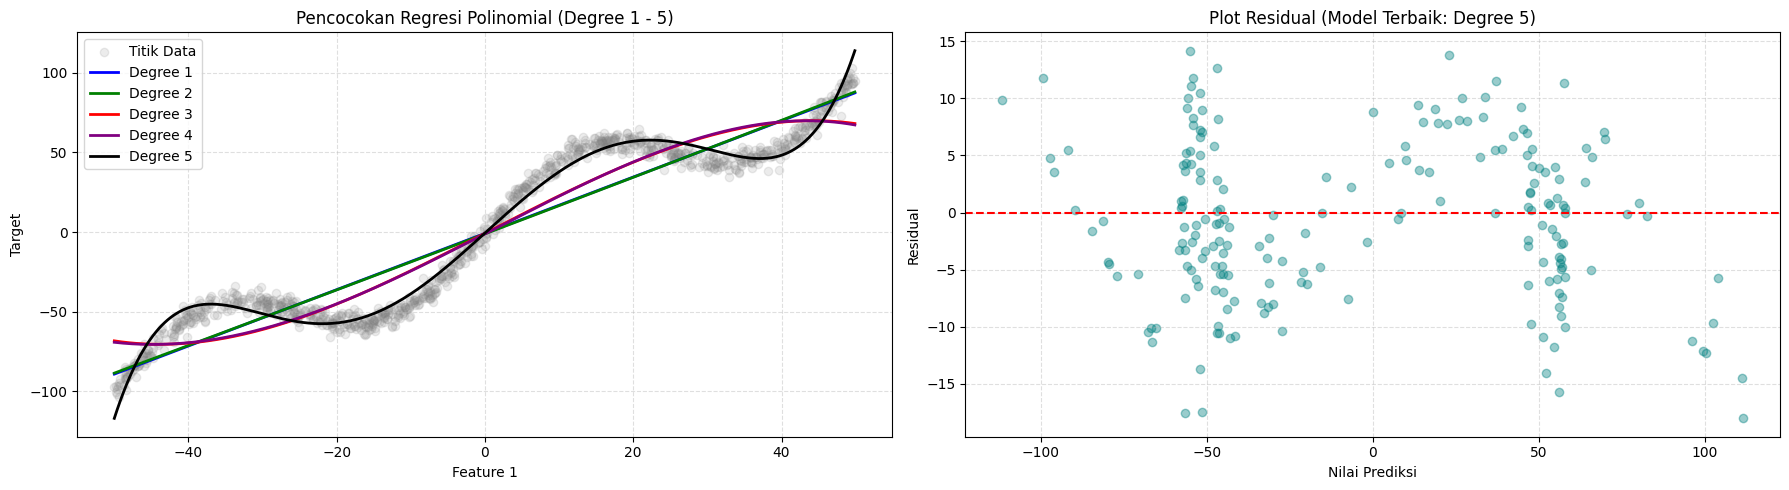

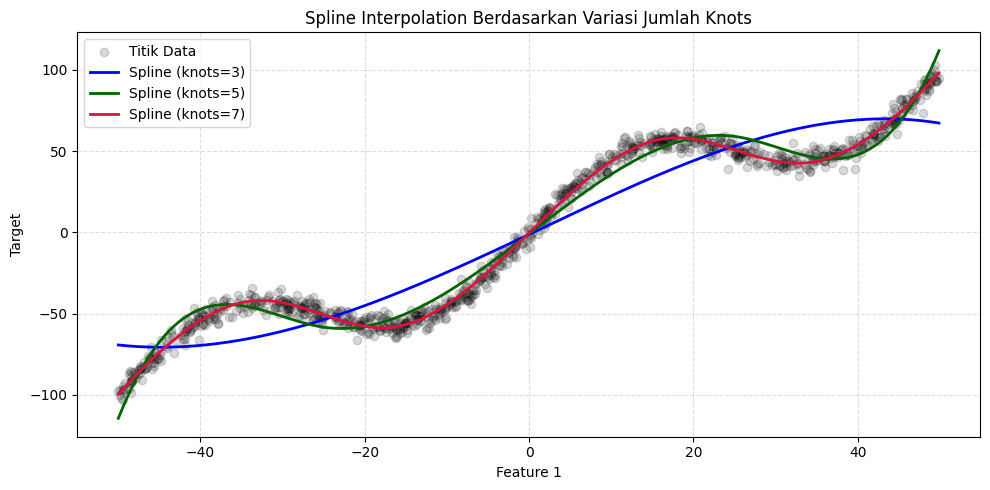

Performa Spline Interpolation:


,Number of Knots,MSE,R-squared
0,3,274.27,0.9047
1,5,55.35,0.9808
2,7,15.50,0.9946


In [11]:
# Visualisasi Polinomial Fits dan Residual Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ax1.scatter(df_curve['feature1'], y_curve, alpha=0.15, color='grey', label='Titik Data')
X_plot_dense = np.linspace(df_curve['feature1'].min(), df_curve['feature1'].max(), 500).reshape(-1, 1)
colors_list = ['blue', 'green', 'red', 'purple', 'black']

for deg, color in zip(degrees, colors_list):
    poly = PolynomialFeatures(degree=deg)
    p_mod = LinearRegression().fit(poly.fit_transform(df_curve[['feature1']]), y_curve)
    y_dense_pred = p_mod.predict(poly.fit_transform(X_plot_dense))
    ax1.plot(X_plot_dense, y_dense_pred, label=f'Degree {deg}', color=color, linewidth=2)

ax1.set_title('Pencocokan Regresi Polinomial (Degree 1 - 5)', fontsize=12)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Target')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

# Plot Sisaan (Residual Plot) Derajat Terbaik (Degree 5)
best_deg = poly_df.loc[poly_df['R2'].idxmax(), 'Degree']
poly_best = PolynomialFeatures(degree=best_deg)
X_best = poly_best.fit_transform(df_curve[['feature1']])
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X_best, y_curve, test_size=0.2, random_state=123)

best_mod = LinearRegression().fit(X_tr_b, y_tr_b)
res = y_te_b - best_mod.predict(X_te_b)

ax2.scatter(best_mod.predict(X_te_b), res, alpha=0.4, color='teal')
ax2.axhline(y=0, color='r', linestyle='--')
ax2.set_title(f'Plot Residual (Model Terbaik: Degree {best_deg})', fontsize=12)
ax2.set_xlabel('Nilai Prediksi')
ax2.set_ylabel('Residual')
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Implementasi SplineTransformer dengan Variasi Knots
knots_list = [3, 5, 7]
plt.figure(figsize=(10, 5))
plt.scatter(df_curve['feature1'], y_curve, color='black', alpha=0.15, label='Titik Data')
spline_metrics = []

for n_knot, col in zip(knots_list, ['blue', 'darkgreen', 'crimson']):
    spline = SplineTransformer(n_knots=n_knot, degree=3)
    spline_pipe = make_pipeline(spline, LinearRegression())
    spline_pipe.fit(df_curve[['feature1']], y_curve)

    y_spline_pred = spline_pipe.predict(X_plot_dense)
    plt.plot(X_plot_dense, y_spline_pred, label=f'Spline (knots={n_knot})', color=col, linewidth=2)

    y_pred_all = spline_pipe.predict(df_curve[['feature1']])
    spline_metrics.append({
        'Number of Knots': n_knot,
        'MSE': mean_squared_error(y_curve, y_pred_all),
        'R-squared': r2_score(y_curve, y_pred_all)
    })

plt.title('Spline Interpolation Berdasarkan Variasi Jumlah Knots', fontsize=12)
plt.xlabel('Feature 1')
plt.ylabel('Target')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("Performa Spline Interpolation:")
display(pd.DataFrame(spline_metrics).style.format({'MSE': '{:.2f}', 'R-squared': '{:.4f}'}))

## 6. Analisis dan Kesimpulan
1. **Dampak Multikolinearitas pada OLS**: Pada dataset dengan korelasi tinggi, OLS mengalami inflasi nilai koefisien yang sangat drastis (norm L2 koefisien mencapai ratusan ribu) dan performa $R^2$ yang rendah. Model gagal mengatribusikan bobot secara stabil pada variabel yang berkorelasi.
2. **Keunggulan Regularisasi**: Regularisasi Ridge, Lasso, dan ElasticNet secara terbukti mampu menekan besaran magnitudo koefisien ke tingkat yang wajar. Lasso mengeliminasi fitur-fitur redundan dengan menetapkan koefisien tepat menjadi nol, sementara ElasticNet menghasilkan keseimbangan optimal pada kelompok fitur yang multikolinear.
3. **Fleksibilitas Pemodelan Non-Linier**: Transformasi polinomial derajat tinggi serta penyesuaian sekat kurva (*knots*) pada `SplineTransformer` mampu memodelkan fungsi sinusoidal kompleks dengan nilai $R^2$ melampaui 0.98. Evaluasi plot sisaan (*residual plot*) membuktikan tidak adanya pola kesalahan sistematis yang tertinggal.